[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/labren/sonda-curadoria/blob/main/01_EDA_Formatados_Solarimetricos.ipynb)

In [1]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np
import seaborn as sns
import pandas as pd
from matplotlib.patches import Patch


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

### Upload Your Files

To upload your data files, run the code cell below. A file explorer window will pop up, allowing you to select the files from your local computer.

The uploaded files will be moved to the `uploaded_files` directory within this Colab environment.

In [ ]:
import os
from google.colab import files
import shutil

# Define the target directory
upload_dir = 'uploaded_files'

# Create the directory if it doesn't exist
if not os.path.exists(upload_dir):
    os.makedirs(upload_dir)
    print(f"Directory '{upload_dir}' created.")
else:
    print(f"Directory '{upload_dir}' already exists.")

# Allow the user to upload files
print("Please upload your files:")
uploaded = files.upload()

# Move the uploaded files to the target directory
for filename in uploaded.keys():
  source_path = f'/content/{filename}'
  destination_path = f'{upload_dir}/{filename}'
  shutil.move(source_path, destination_path)
  print(f'Moved "{filename}" to "{upload_dir}/"')

Lendo Arquivos

In [ ]:
df = pd.read_csv('uploaded_files/solar_validated_BRB_2018-03.csv', sep=';')
df['timestamp'] = pd.to_datetime(df['timestamp'], format='%Y-%m-%d %H:%M:%S')
df = df.set_index('timestamp')

df.head(100)


,acronym,year,day,min,glo_avg,glo_avg_dqc,dir_avg,dir_avg_dqc,dif_avg,dif_avg_dqc,lw_avg,lw_avg_dqc,par_avg,par_avg_dqc,lux_avg,lux_avg_dqc
timestamp,,,,,,,,,,,,,,,,
2018-12-01 00:00:00,BRB,2018.0,335.0,0.0,-0.365,995,-0.060,999,-0.627,295,387.2,99,0.0,29,0.0,29
2018-12-01 00:00:00,BRB,2018.0,335.0,0.0,-0.365,995,-0.060,999,-0.627,295,387.2,99,0.0,29,0.0,29
2018-12-01 00:00:00,BRB,2018.0,335.0,0.0,-0.365,995,-0.060,999,-0.627,295,387.2,99,0.0,29,0.0,29
2018-12-01 00:10:00,BRB,2018.0,335.0,10.0,-0.701,295,0.000,299,-0.494,995,388.1,99,0.0,29,0.0,29
2018-12-01 00:10:00,BRB,2018.0,335.0,10.0,-0.701,295,0.000,299,-0.494,995,388.1,99,0.0,29,0.0,29
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2018-12-01 05:10:00,BRB,2018.0,335.0,310.0,-0.701,295,-0.082,999,-0.593,995,376.1,99,0.0,29,0.0,29
2018-12-01 05:20:00,BRB,2018.0,335.0,320.0,-0.724,995,0.000,299,-0.627,295,382.9,99,0.0,29,0.0,29
2018-12-01 05:20:00,BRB,2018.0,335.0,320.0,-0.724,995,0.000,299,-0.627,295,382.9,99,0.0,29,0.0,29


Show available days in data:

In [3]:
df.index.unique()

DatetimeIndex(['2018-12-01 00:00:00', '2018-12-01 00:10:00',
               '2018-12-01 00:20:00', '2018-12-01 00:30:00',
               '2018-12-01 00:40:00', '2018-12-01 00:50:00',
               '2018-12-01 01:00:00', '2018-12-01 01:10:00',
               '2018-12-01 01:20:00', '2018-12-01 01:30:00',
               ...
               '2018-12-31 22:20:00', '2018-12-31 22:30:00',
               '2018-12-31 22:40:00', '2018-12-31 22:50:00',
               '2018-12-31 23:00:00', '2018-12-31 23:10:00',
               '2018-12-31 23:20:00', '2018-12-31 23:30:00',
               '2018-12-31 23:40:00', '2018-12-31 23:50:00'],
              dtype='datetime64[ns]', name='timestamp', length=4464, freq=None)

Select one day to plot:

In [18]:
df_selected = df[(df.index >='2018-12-01') & (df.index<'2018-12-02')]
df_selected

,acronym,year,day,min,glo_avg,glo_avg_dqc,dir_avg,dir_avg_dqc,dif_avg,dif_avg_dqc,lw_avg,lw_avg_dqc,par_avg,par_avg_dqc,lux_avg,lux_avg_dqc
timestamp,,,,,,,,,,,,,,,,
2018-12-01 00:00:00,BRB,2018.0,335.0,0.0,-0.365,995,-0.060,999,-0.627,295,387.2,99,0.0,29,0.0,29
2018-12-01 00:00:00,BRB,2018.0,335.0,0.0,-0.365,995,-0.060,999,-0.627,295,387.2,99,0.0,29,0.0,29
2018-12-01 00:00:00,BRB,2018.0,335.0,0.0,-0.365,995,-0.060,999,-0.627,295,387.2,99,0.0,29,0.0,29
2018-12-01 00:10:00,BRB,2018.0,335.0,10.0,-0.701,295,0.000,299,-0.494,995,388.1,99,0.0,29,0.0,29
2018-12-01 00:10:00,BRB,2018.0,335.0,10.0,-0.701,295,0.000,299,-0.494,995,388.1,99,0.0,29,0.0,29
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2018-12-01 23:40:00,BRB,2018.0,335.0,1420.0,-0.564,995,-0.030,999,-0.486,995,398.8,99,0.0,29,0.0,29
2018-12-01 23:40:00,BRB,2018.0,335.0,1420.0,-0.564,995,-0.030,999,-0.486,995,398.8,99,0.0,29,0.0,29
2018-12-01 23:50:00,BRB,2018.0,335.0,1430.0,-0.497,995,-0.195,999,-0.481,995,395.8,99,0.0,29,0.0,29


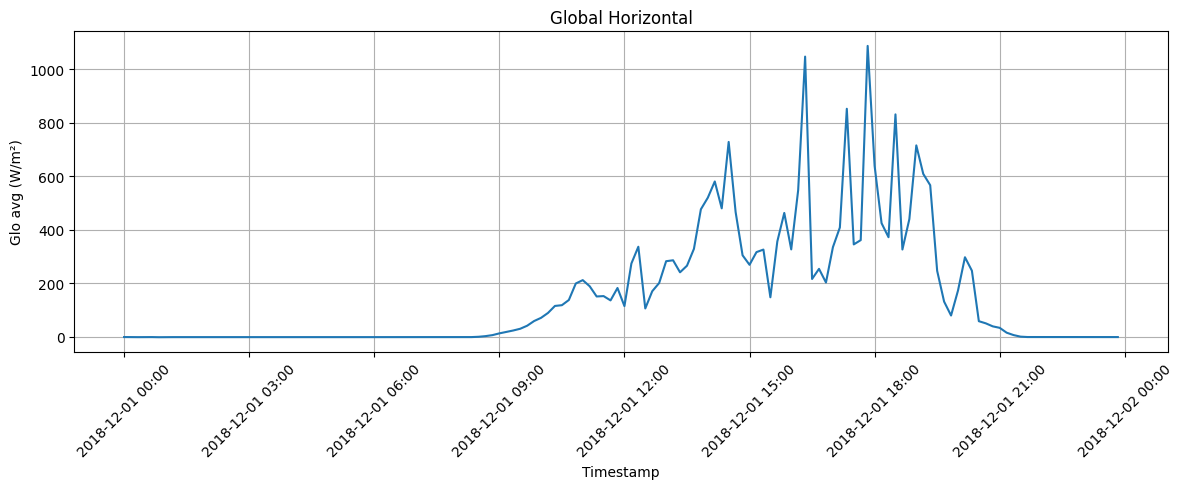

In [19]:
#Plota dados - alterar varíavel

plt.figure(figsize=(12,5))
plt.plot(df_selected.index, df_selected['glo_avg'])
plt.title('Global Horizontal')
plt.xlabel('Timestamp')
plt.ylabel('Glo avg (W/m²)')

plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d %H:%M'))
plt.gca().xaxis.set_major_locator(mdates.AutoDateLocator())
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()


In [6]:
# Analyze DQC columns in the dataset
print("Available columns:")
print(df.columns.tolist())

print("\nDQC columns:")
dqc_columns = [col for col in df.columns if 'dqc' in col.lower()]
print(dqc_columns)

print("\nSample DQC values:")
for col in dqc_columns[:3]:  # Show first 3 DQC columns
    print(f"\n{col}:")
    print(df[col].value_counts().head(10))

# Debug: Check actual DQC values
print("\n" + "="*50)
print("DEBUGGING DQC VALUES")
print("="*50)
for col in dqc_columns[:2]:
    print(f"\n{col}:")
    sample_values = df[col].head(5).tolist()
    print(f"Sample values: {sample_values}")
    print(f"Data type: {type(sample_values[0])}")
    print(f"Unique values (first 10): {df[col].unique()[:10]}")


Available columns:
['acronym', 'year', 'day', 'min', 'glo_avg', 'glo_avg_dqc', 'dir_avg', 'dir_avg_dqc', 'dif_avg', 'dif_avg_dqc', 'lw_avg', 'lw_avg_dqc', 'par_avg', 'par_avg_dqc', 'lux_avg', 'lux_avg_dqc']

DQC columns:
['glo_avg_dqc', 'dir_avg_dqc', 'dif_avg_dqc', 'lw_avg_dqc', 'par_avg_dqc', 'lux_avg_dqc']

Sample DQC values:

glo_avg_dqc:
glo_avg_dqc
995    6243
999    6222
295     711
925     180
225      24
929      12
Name: count, dtype: int64

dir_avg_dqc:
dir_avg_dqc
992    5976
999    4479
299    2754
292     138
922      36
222       6
929       3
Name: count, dtype: int64

dif_avg_dqc:
dif_avg_dqc
999    6237
995    4143
295    2937
299      57
225      12
925       6
Name: count, dtype: int64

DEBUGGING DQC VALUES

glo_avg_dqc:
Sample values: [995, 995, 995, 295, 295]
Data type: <class 'int'>
Unique values (first 10): [995 295 999 925 225 929]

dir_avg_dqc:
Sample values: [999, 999, 999, 299, 299]
Data type: <class 'int'>
Unique values (first 10): [999 299 292 992 922 929 

In [16]:
def create_enhanced_dqc_plot(df, dqc_columns):
    """
    Create an enhanced DQC status plot with dynamic color coding:
    - Blue for 999 and 99 status (good data)
    - Red for other statuses (suspect/missing data)
    """
    # Get unique days in the dataset
    unique_days = pd.Series(df.index.date).unique()
    unique_days = sorted(list(unique_days))
    
    print(f"Found {len(unique_days)} unique days in the dataset")
    print(f"Date range: {unique_days[0]} to {unique_days[-1]}")
    
    # Create figure with subplots for each DQC column
    n_cols = len(dqc_columns)
    fig, axes = plt.subplots(n_cols, 1, figsize=(16, 5*n_cols))
    
    if n_cols == 1:
        axes = [axes]
    
    for idx, dqc_col in enumerate(dqc_columns):
        ax = axes[idx]
        
        # Get all unique DQC values for this column
        dqc_values = df[dqc_col].dropna()
        unique_dqc_codes = dqc_values.unique()
        
        print(f"\n{dqc_col} - Unique DQC codes found: {sorted(unique_dqc_codes)}")
        
        # Create a matrix to store DQC status for each day and time
        time_slots = df.index.time
        unique_times = sorted(list(set(time_slots)))
        
        # Create a 2D array: days x time_slots
        dqc_matrix = np.full((len(unique_days), len(unique_times)), np.nan)
        
        # Fill the matrix with DQC values
        for i, day in enumerate(unique_days):
            day_data = df[df.index.date == day]
            for j, time_slot in enumerate(unique_times):
                time_data = day_data[day_data.index.time == time_slot]
                if not time_data.empty:
                    dqc_value = time_data[dqc_col].iloc[0]
                    
                    # CORRECTED: Preserve full DQC codes, only 999 and 99 are blue
                    if pd.isna(dqc_value):
                        dqc_matrix[i, j] = np.nan
                    else:
                        dqc_str = str(int(dqc_value))
                        if dqc_str == '999' or dqc_str == '99':
                            dqc_matrix[i, j] = 9  # Blue (good)
                        else:
                            dqc_matrix[i, j] = 2  # Red (suspect/missing)
        
        # Create time axis labels
        time_labels = [t.strftime('%H:%M') for t in unique_times]
        
        # Create the heatmap with custom colormap
        colors = ['red', 'red', 'red', 'red', 'red', 'red', 'red', 'red', 'blue']
        cmap = plt.cm.colors.ListedColormap(colors)
        
        im = ax.imshow(dqc_matrix, cmap=cmap, aspect='auto', 
                      vmin=0, vmax=9, interpolation='nearest')
        
        # Set labels and title
        ax.set_title(f'DQC Status: {dqc_col}', fontsize=14, fontweight='bold', pad=20)
        ax.set_xlabel('Time of Day', fontsize=12)
        ax.set_ylabel('Day of Month', fontsize=12)
        
        # Set x-axis labels (time) - show every 2nd hour
        step = max(1, len(unique_times)//12)  # Show about 12 time labels
        ax.set_xticks(range(0, len(unique_times), step))
        ax.set_xticklabels([time_labels[i] for i in range(0, len(unique_times), step)])
        
        # Set y-axis labels (days)
        day_labels = [day.strftime('%d') for day in unique_days]
        ax.set_yticks(range(len(unique_days)))
        ax.set_yticklabels(day_labels)
        
        # Add colorbar with custom labels
        cbar = plt.colorbar(im, ax=ax, shrink=0.8, pad=0.02)
        cbar.set_label('DQC Status', rotation=270, labelpad=20, fontsize=12)
        
        # Custom colorbar labels
        cbar.set_ticks([2, 9])
        cbar.set_ticklabels(['Suspect/Missing\n(Red)', 'Good Data\n(Blue)'])
        
        # Rotate x-axis labels for better readability
        plt.setp(ax.get_xticklabels(), rotation=45, ha='right')
        
        # Add grid for better readability
        ax.grid(True, alpha=0.3, linewidth=0.5)
        
        # Add legend
        legend_elements = [
            Patch(facecolor='blue', label='999/99 - Good Data'),
            Patch(facecolor='red', label='Other - Suspect/Missing Data')
        ]
        ax.legend(handles=legend_elements, loc='upper right', fontsize=10)
        
        # Print detailed statistics for this column
        dqc_counts = dqc_values.value_counts().sort_index()
        total_count = len(dqc_values)
        
        print(f"Total observations: {total_count:,}")
        print("DQC Status Distribution:")
        for status, count in dqc_counts.items():
            percentage = (count / total_count) * 100
            status_type = "Good Data" if str(status) in ['999', '99'] else "Suspect/Missing Data"
            print(f"  {status}: {count:,} ({percentage:.1f}%) - {status_type}")
        
        # Calculate data availability
        good_data = dqc_counts.get('999', 0) + dqc_counts.get('99', 0)
        data_availability = (good_data / total_count) * 100
        print(f"Data Availability: {data_availability:.1f}%")
    
    plt.tight_layout()
    plt.show()
    
    return fig
    


DQC columns found: ['glo_avg_dqc', 'dir_avg_dqc', 'dif_avg_dqc', 'lw_avg_dqc', 'par_avg_dqc', 'lux_avg_dqc']
Found 31 unique days in the dataset
Date range: 2018-12-01 to 2018-12-31

glo_avg_dqc - Unique DQC codes found: [np.int64(225), np.int64(295), np.int64(925), np.int64(929), np.int64(995), np.int64(999)]
Total observations: 13,392
DQC Status Distribution:
  225: 24 (0.2%) - Suspect/Missing Data
  295: 711 (5.3%) - Suspect/Missing Data
  925: 180 (1.3%) - Suspect/Missing Data
  929: 12 (0.1%) - Suspect/Missing Data
  995: 6,243 (46.6%) - Suspect/Missing Data
  999: 6,222 (46.5%) - Good Data
Data Availability: 0.0%

dir_avg_dqc - Unique DQC codes found: [np.int64(222), np.int64(292), np.int64(299), np.int64(922), np.int64(929), np.int64(992), np.int64(999)]
Total observations: 13,392
DQC Status Distribution:
  222: 6 (0.0%) - Suspect/Missing Data
  292: 138 (1.0%) - Suspect/Missing Data
  299: 2,754 (20.6%) - Suspect/Missing Data
  922: 36 (0.3%) - Suspect/Missing Data
  929: 3 (0.

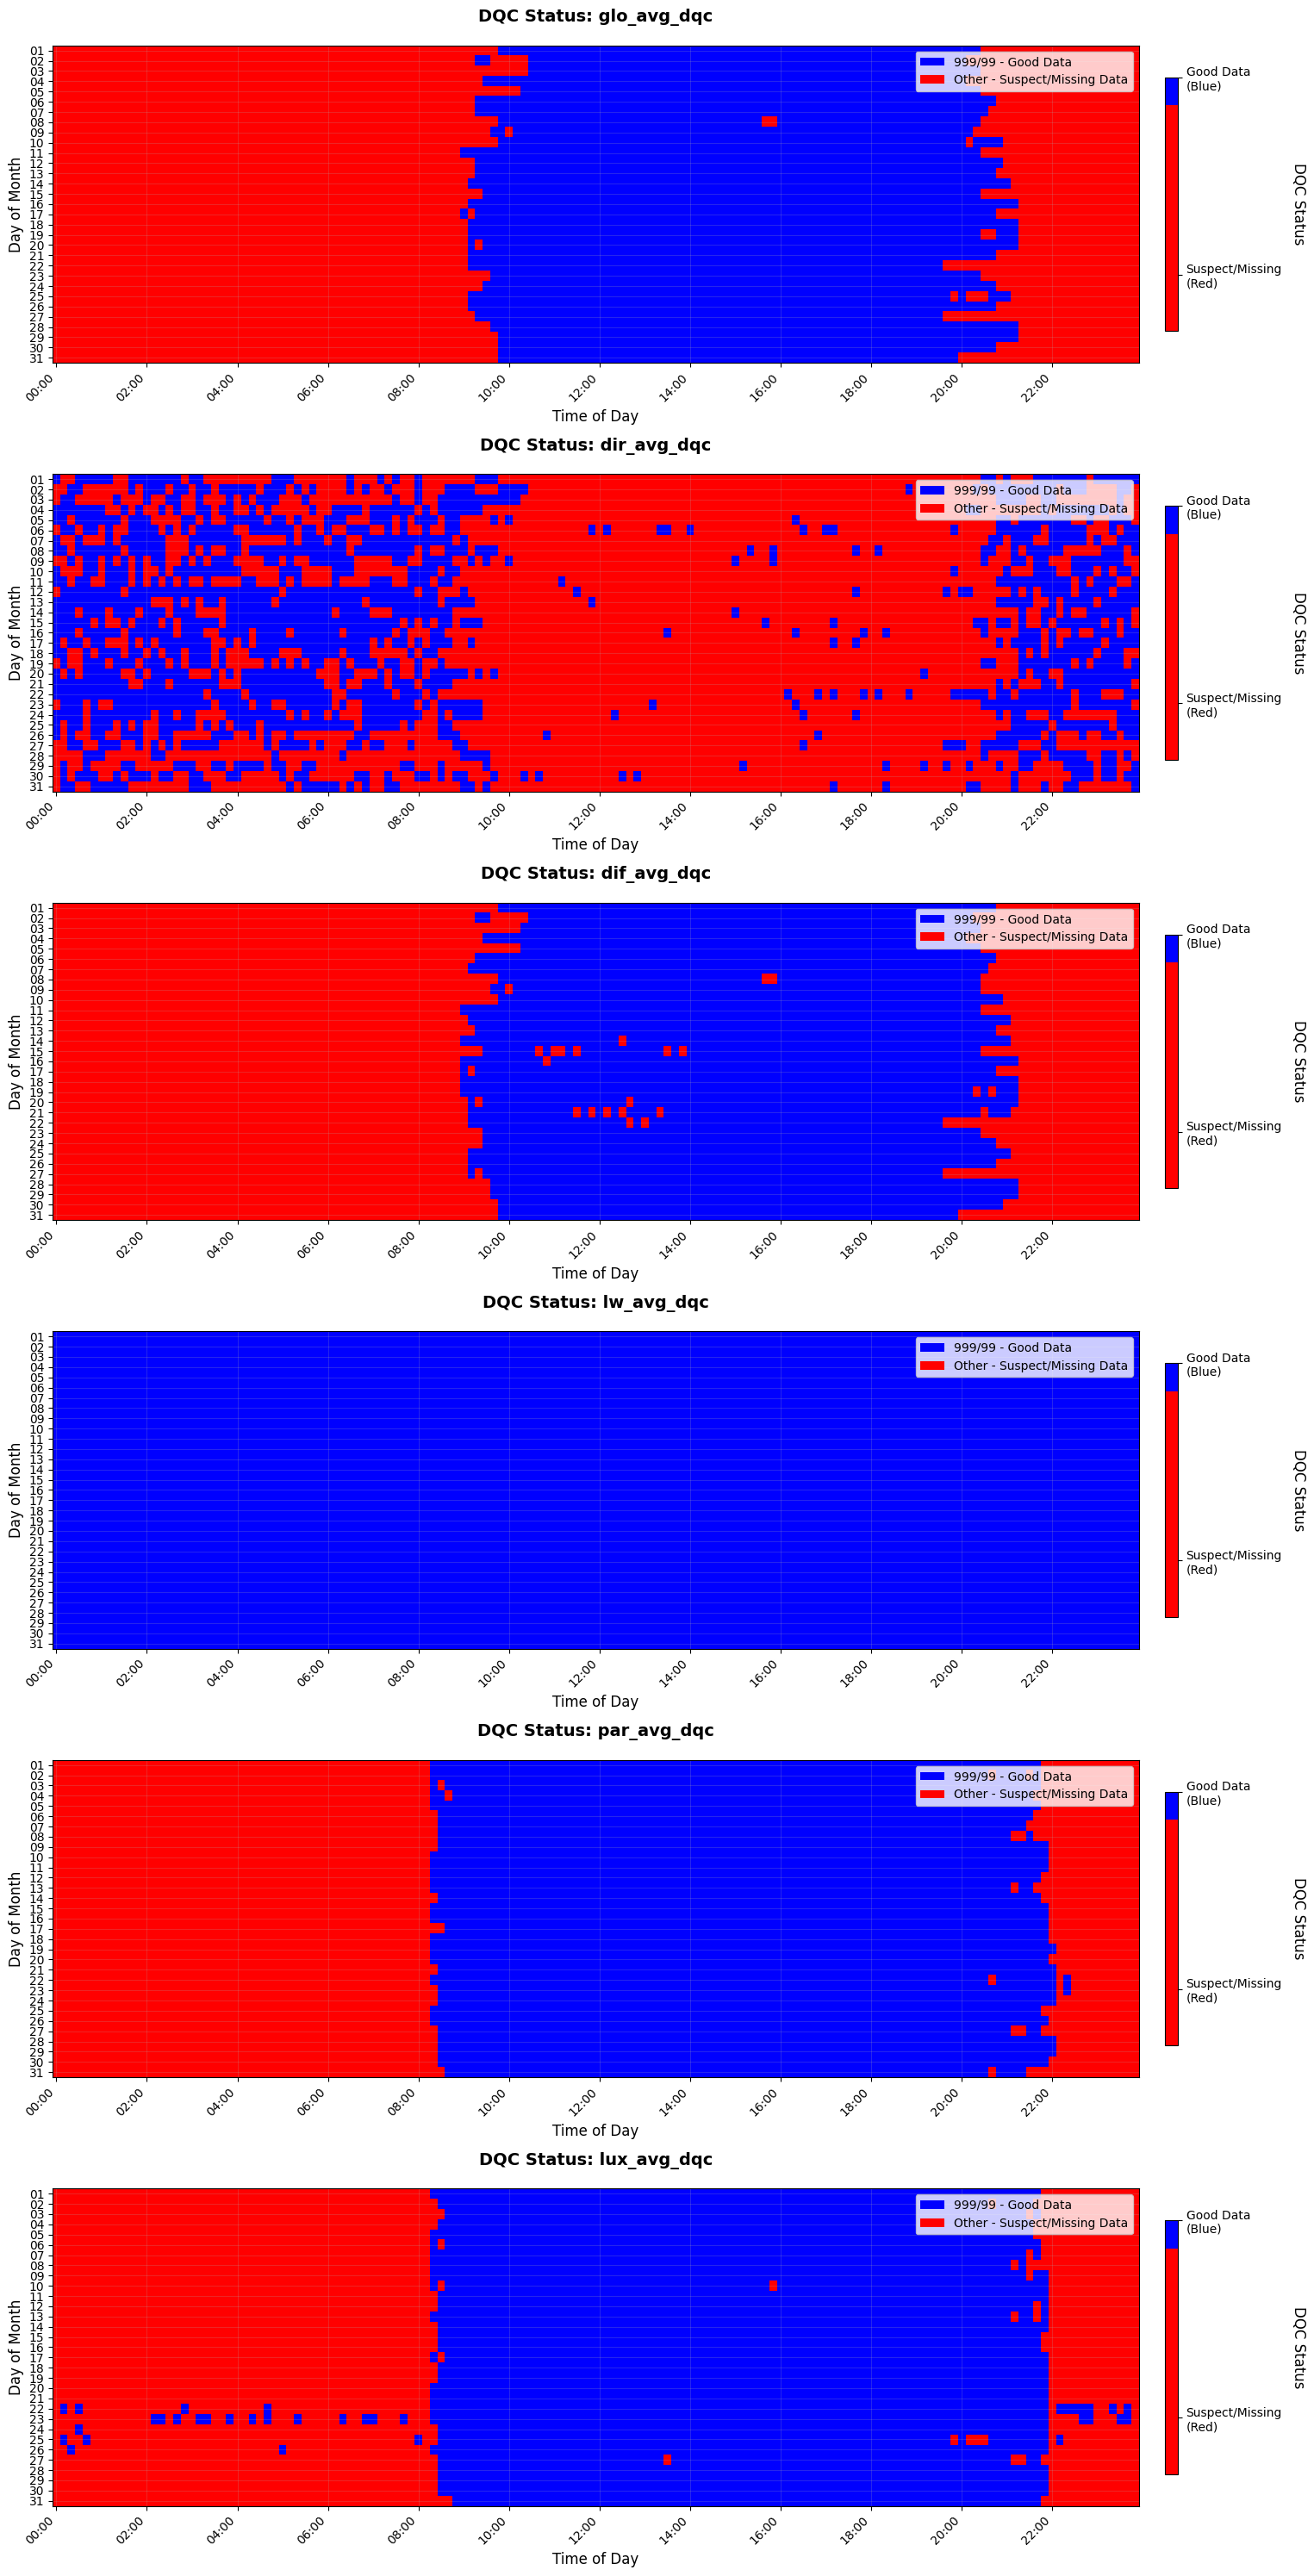

In [17]:
# Get DQC columns
dqc_columns = [col for col in df.columns if 'dqc' in col.lower()]
print("DQC columns found:", dqc_columns)

# Then call the function
fig = create_enhanced_dqc_plot(df, dqc_columns)